In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
BASE_PATH = os.path.dirname(os.getcwd())
LABELED_DATASET = BASE_PATH + "/datasets/material"
FILES = []
for path, folders, files in os.walk(LABELED_DATASET) : 
    for file in files : 
        FILES.append(f"{path}/{file}")
FILES

['d:\\CODE FOLDER\\Projects\\PUBLICATION\\Publication - 1/datasets/material/test.xlsx',
 'd:\\CODE FOLDER\\Projects\\PUBLICATION\\Publication - 1/datasets/material/training.xlsx']

In [5]:
df_1 = pd.read_excel(FILES[0]).loc[:,["text","label"]]
df_2 = pd.read_excel(FILES[1]).loc[:,["text","label"]]

In [9]:
df = pd.concat([df_1, df_2], axis = 0)
df

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0
...,...,...
17995,im having ssa examination tomorrow in the morn...,0
17996,i constantly worry about their fight against n...,1
17997,i feel its important to share this info for th...,1
17998,i truly feel that if you are passionate enough...,1


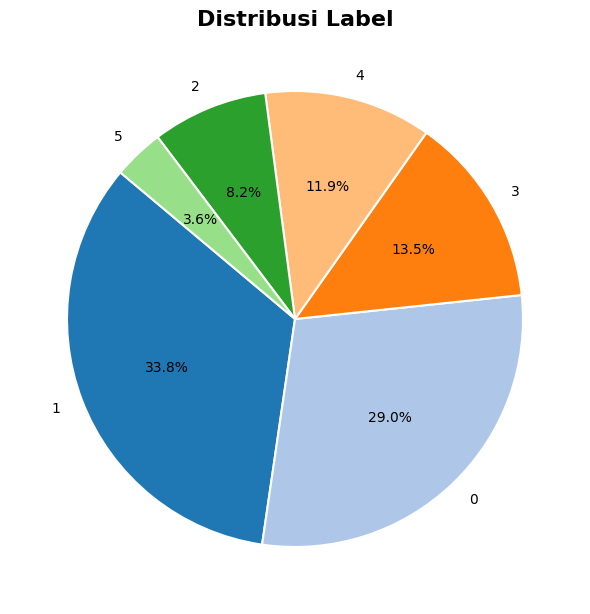

In [13]:
label_counts = df["label"].value_counts()
plt.figure(figsize=(6,8))
colors = plt.cm.tab20.colors  # Palet profesional
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title("Distribusi Label", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import re

def cleaning(data) : 
    text = data["text"]
    text = re.sub(pattern = r"[^a-zA-Z0-9\s]", repl = " ", string = text)
    text = re.sub(pattern = r"\s+", repl = " ", string = text)    
    return text

df["Cleaned_Text"] = df.apply(cleaning, axis=1)

In [18]:
def calculate_token(data) : 
    text = data["text"]
    return len(text.split(" "))

df["Long_Token_Approximate"] = df.apply(calculate_token, axis=1)

In [19]:
df

,text,label,Cleaned_Text,Long_Token_Approximate
0,im feeling rather rotten so im not very ambiti...,0,im feeling rather rotten so im not very ambiti...,11
1,im updating my blog because i feel shitty,0,im updating my blog because i feel shitty,8
2,i never make her separate from me because i do...,0,i never make her separate from me because i do...,22
3,i left with my bouquet of red and yellow tulip...,1,i left with my bouquet of red and yellow tulip...,21
4,i was feeling a little vain when i did this one,0,i was feeling a little vain when i did this one,11
...,...,...,...,...
17995,im having ssa examination tomorrow in the morn...,0,im having ssa examination tomorrow in the morn...,34
17996,i constantly worry about their fight against n...,1,i constantly worry about their fight against n...,29
17997,i feel its important to share this info for th...,1,i feel its important to share this info for th...,15
17998,i truly feel that if you are passionate enough...,1,i truly feel that if you are passionate enough...,19


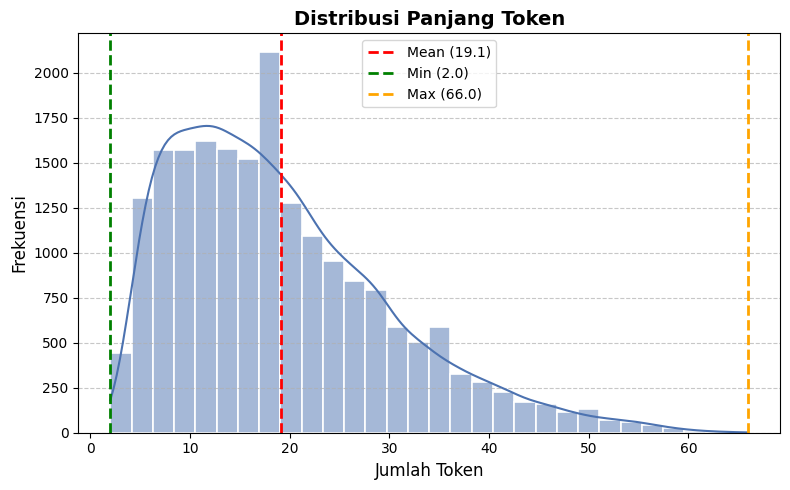

In [20]:
import seaborn as sns

data = df["Long_Token_Approximate"]
mean_val = data.mean()
min_val = data.min()
max_val = data.max()

plt.figure(figsize=(8,5))
sns.histplot(data, 
             kde=True, 
             bins=30,         
             color="#4C72B0",  
             edgecolor='white', 
             linewidth=1.2)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.1f})')
plt.axvline(min_val, color='green', linestyle='--', linewidth=2, label=f'Min ({min_val:.1f})')
plt.axvline(max_val, color='orange', linestyle='--', linewidth=2, label=f'Max ({max_val:.1f})')
plt.title("Distribusi Panjang Token", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Token", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
import pickle

with open(f"{BASE_PATH}/datasets/material/readyDataset.pkl", "wb") as f : 
    pickle.dump(df,f)
print("SAVED")

SAVED
